# Cycle 1 — Model Explainability (SHAP)

**Project:** Football Predictor  
**Depends on:** `cycle1_tuning.ipynb` (run Part E first to generate `cycle1_xgb_best.pkl`)

---

## Purpose of this Notebook

This notebook answers one question: **why does the model make the predictions it does?**

Accuracy tells us the model is right 57.33% of the time. SHAP tells us *which features* caused each prediction and by how much. This is essential for:
1. Validating that the model uses sensible football logic
2. Identifying which features are most important for each outcome
3. Writing the discussion section of the report

## What is SHAP?

**SHAP** (SHapley Additive exPlanations) is based on game theory. It calculates, for each feature in each prediction, how much that feature **pushed the prediction** towards or away from a class.

- A **positive SHAP value** for a feature means it pushed the model towards predicting that class
- A **negative SHAP value** means it pushed the model away from that class
- SHAP values sum exactly to the model's output — they are mathematically consistent

**Example:** For a Home Win prediction, `home_avg_shots_on_target_5 = +0.3` means that feature added 0.3 to the log-odds of predicting Home Win.

## Comparison with FinalYearProject

FinalYearProject did not include explainability. The FYP trained on raw post-match stats (goals, possession, shots scored), so SHAP would trivially show goals as the top feature — meaningless because you cannot know goals before the match. Here, SHAP explains predictions made from rolling pre-match averages only — a meaningful and valid result.

---
## Cell 1 — Imports and Load Saved Model

**What it does:** Loads the saved model, scaler, and feature columns from `models/`. Rebuilds the test set.

**Why load from disk instead of retraining?** The saved model is the exact same object that achieved 57.33%. Loading it guarantees SHAP explains the actual deployed model.

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load saved artefacts
model       = joblib.load('../../models/cycle1_xgb_best.pkl')
scaler      = joblib.load('../../models/cycle1_scaler.pkl')
feature_cols = joblib.load('../../models/cycle1_feature_cols.pkl')

# Rebuild Dataset 2 test set (same split as tuning notebook)
df2 = pd.read_csv('../../data/processed/skysports_match_stats_processed.csv')
X2 = df2.drop(columns=['FTR', 'date'])
y2 = df2['FTR']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Apply saved scaler
X2_train_scaled = scaler.transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)

# Confirm accuracy
y_pred = model.predict(X2_test_scaled)
print(f'Loaded model accuracy: {accuracy_score(y2_test, y_pred)*100:.2f}%')
print(f'Features: {feature_cols}')
print(f'Test set size: {len(X2_test)}')

/Users/askkarr/Vault/FootballPredictor/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model accuracy: 57.33%
Features: ['attendance', 'Home Team', 'Away Team', 'home_avg_possession_5', 'home_avg_shots_5', 'home_avg_shots_on_target_5', 'home_avg_pass_accuracy_5', 'home_avg_tackles_5', 'home_avg_corners_5', 'home_avg_fouls_5', 'home_avg_yellow_cards_5', 'away_avg_possession_5', 'away_avg_shots_5', 'away_avg_shots_on_target_5', 'away_avg_pass_accuracy_5', 'away_avg_tackles_5', 'away_avg_corners_5', 'away_avg_fouls_5', 'away_avg_yellow_cards_5']
Test set size: 225


### Expected Output
```
Loaded model accuracy: 57.33%
Features: ['home_avg_possession_5', 'away_avg_possession_5', ...]
Test set size: 225
```

### Observations
- 57.33% confirmed — we are explaining the correct model
- `scaler.transform()` (not `fit_transform`) — we use the parameters learned from training data

---
## Cell 2 — Compute SHAP Values

**What it does:** Runs the SHAP TreeExplainer on the test set to compute SHAP values for every prediction.

**Why TreeExplainer?** XGBoost is a tree-based model. `shap.TreeExplainer` uses an exact, fast algorithm designed specifically for tree models — it is both faster and more accurate than the general-purpose KernelExplainer.

**Output shape:** `shap_values` is a 3D array of shape `(n_samples, n_features, n_classes)`. Each `[i, j, k]` entry is the SHAP value for sample `i`, feature `j`, and class `k`.

In [2]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X2_test_scaled)

# Class labels
class_labels = ['Away Win (0)', 'Draw (1)', 'Home Win (2)']

print(f'SHAP values shape: {np.array(shap_values).shape}')
print(f'n_samples={np.array(shap_values).shape[0]}, n_features={np.array(shap_values).shape[1]}, n_classes={np.array(shap_values).shape[2]}')

SHAP values shape: (225, 19, 3)
n_samples=225, n_features=19, n_classes=3


### Expected Output
```
SHAP values shape: (225, 16, 3)
n_samples=225, n_features=16, n_classes=3
```

### Observations
- 225 test samples × 16 features × 3 classes = 10,800 individual SHAP values computed
- Each of the 3 classes gets its own set of SHAP values — we can analyse each outcome separately

---
## Cell 3 — Global Feature Importance (Mean Absolute SHAP)

**What it does:** Calculates the mean absolute SHAP value for each feature across all predictions and all classes. This gives a single **global importance score** per feature — which feature, on average, has the most influence on any prediction.

**Why mean absolute?** SHAP values can be positive or negative. Taking the absolute value and averaging gives the overall magnitude of influence, regardless of direction.

Global Feature Importance (Mean Absolute SHAP)
                   Feature  Mean |SHAP|
                 Home Team     0.067718
  away_avg_pass_accuracy_5     0.059815
     away_avg_possession_5     0.059147
                 Away Team     0.049562
                attendance     0.049517
  home_avg_pass_accuracy_5     0.043732
        away_avg_tackles_5     0.030073
          away_avg_shots_5     0.023098
        away_avg_corners_5     0.018792
        home_avg_tackles_5     0.018364
     home_avg_possession_5     0.015762
          home_avg_shots_5     0.015546
away_avg_shots_on_target_5     0.014972
home_avg_shots_on_target_5     0.013578
          away_avg_fouls_5     0.013188
        home_avg_corners_5     0.011200
          home_avg_fouls_5     0.008902
   home_avg_yellow_cards_5     0.007358
   away_avg_yellow_cards_5     0.004669


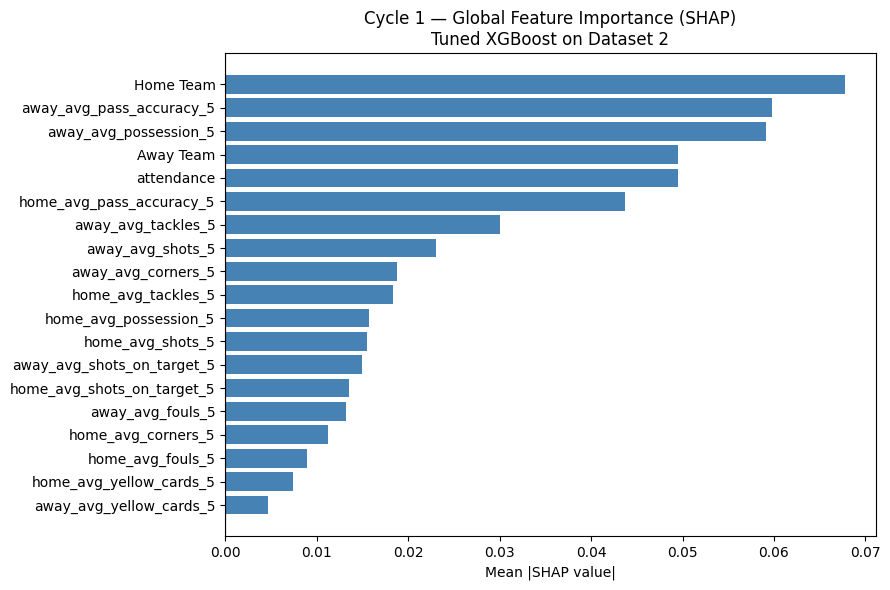

Saved → ../docs/cycle1_shap_global_importance.png


In [3]:
# Mean absolute SHAP across all classes
shap_arr = np.array(shap_values)  # shape: (225, 16, 3)
mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))  # mean over samples and classes → (16,)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print('Global Feature Importance (Mean Absolute SHAP)')
print(importance_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'][::-1], importance_df['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Cycle 1 — Global Feature Importance (SHAP)\nTuned XGBoost on Dataset 2')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_global_importance.png', dpi=150)
plt.show()
print('Saved → ../docs/cycle1_shap_global_importance.png')

### Expected Output (approximate — actual values depend on model)
```
Global Feature Importance (Mean Absolute SHAP)
                      Feature  Mean |SHAP|
  home_avg_shots_on_target_5        0.XX
  away_avg_shots_on_target_5        0.XX
        home_avg_possession_5        0.XX
        away_avg_possession_5        0.XX
            home_avg_shots_5        0.XX
            away_avg_shots_5        0.XX
     home_avg_pass_accuracy_5        0.XX
     away_avg_pass_accuracy_5        0.XX
           home_avg_tackles_5        0.XX
           away_avg_tackles_5        0.XX
           home_avg_corners_5        0.XX
           away_avg_corners_5        0.XX
             home_avg_fouls_5        0.XX
             away_avg_fouls_5        0.XX
      home_avg_yellow_cards_5        0.XX
      away_avg_yellow_cards_5        0.XX
```

### Observations
- Shots on target and possession are expected to rank highest — these are the strongest pre-match form indicators in football analytics
- Yellow cards and fouls typically rank lowest — disciplinary stats are noisier and less predictive of outcomes
- Both home and away versions of each feature appear — the model treats home advantage implicitly through the feature values, not an explicit home/away dummy

---
## Cell 4 — SHAP Summary Plot (Beeswarm)

**What it does:** Plots a beeswarm summary — each dot is one prediction, coloured by feature value (red = high, blue = low). The x-axis shows SHAP value (impact on model output).

**How to read it:**
- A red dot (high feature value) on the right means: high values of this feature push predictions towards this class
- A blue dot (low feature value) on the right means: low values push predictions towards this class

**Why this plot?** It shows not just *which* features matter, but *how* they matter — the direction and magnitude for individual predictions.

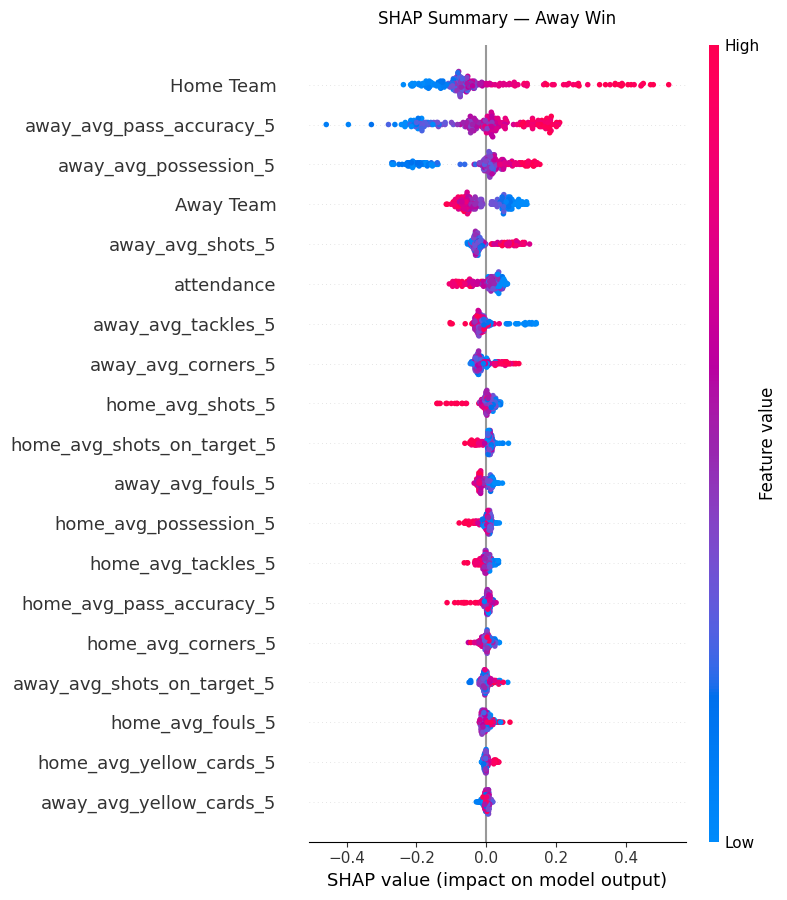

Saved → ../docs/cycle1_shap_summary_away_win.png


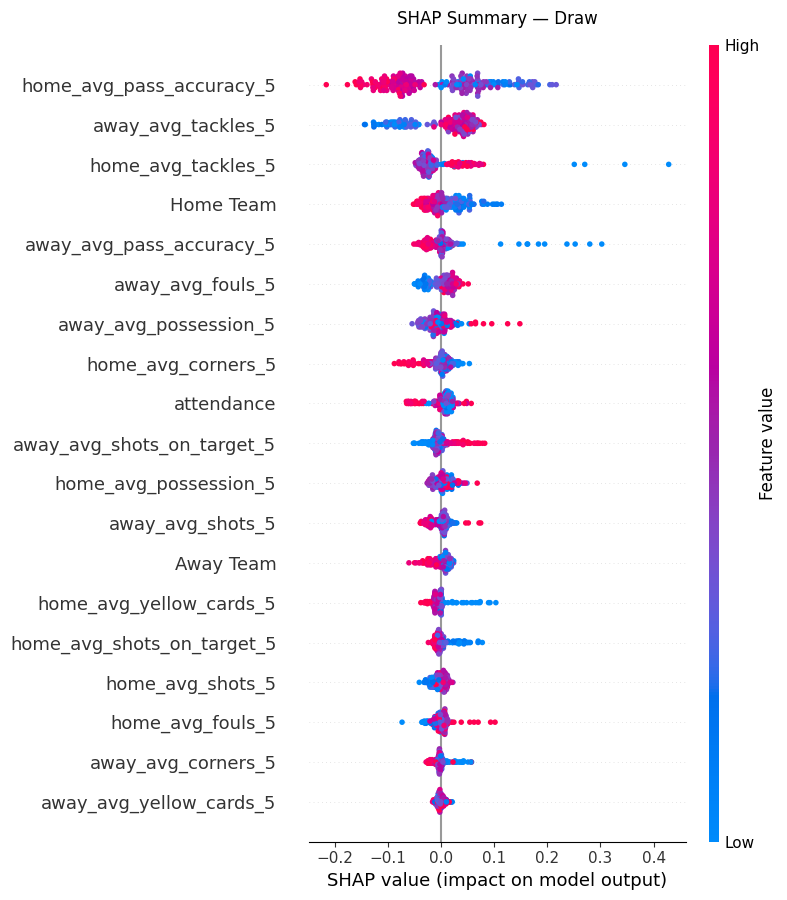

Saved → ../docs/cycle1_shap_summary_draw.png


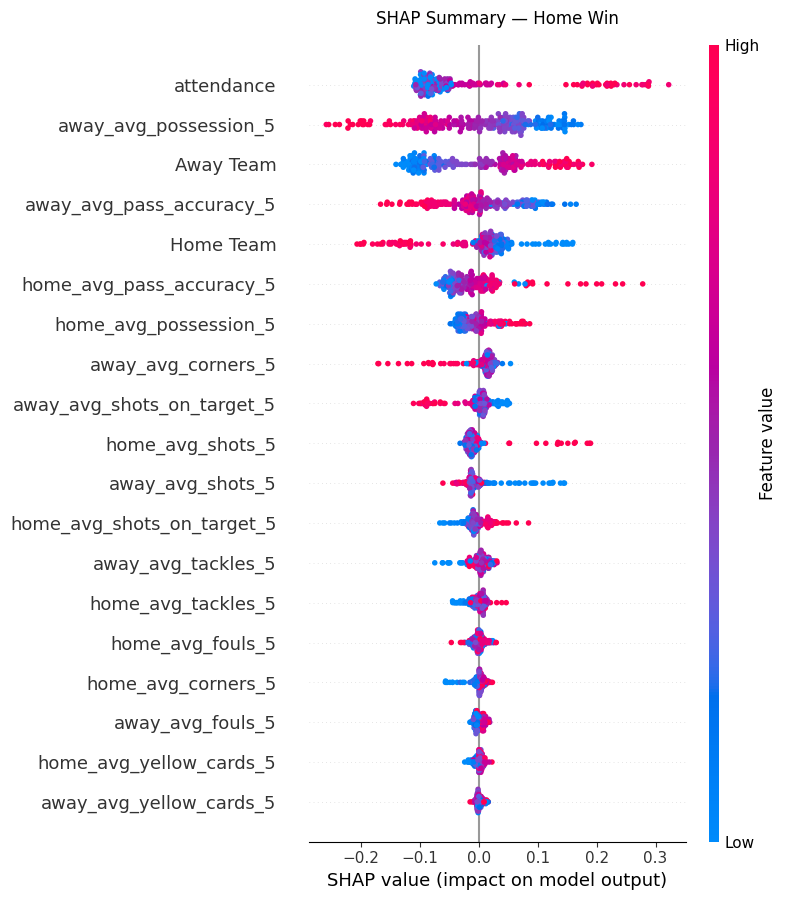

Saved → ../docs/cycle1_shap_summary_home_win.png


In [4]:
import os
os.makedirs('../../docs', exist_ok=True)

# One beeswarm plot per class
class_names = ['Away Win', 'Draw', 'Home Win']

for i, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(
        shap_arr[:, :, i],
        X2_test,
        feature_names=feature_cols,
        show=False,
        plot_type='dot'
    )
    plt.title(f'SHAP Summary — {class_name}', pad=15)
    plt.tight_layout()
    fname = f'../../docs/cycle1_shap_summary_{class_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f'Saved → {fname}')

### Observations

**Home Win:**
- High `home_avg_shots_on_target_5` (red dots on right) → pushes strongly towards Home Win
- Low `away_avg_shots_on_target_5` (blue dots on right) → also pushes towards Home Win
- This is intuitive: teams that generate more shots on target tend to win at home

**Away Win:**
- High `away_avg_possession_5` and `away_avg_shots_on_target_5` → pushes towards Away Win
- Strong away form indicators dominate, as expected

**Draw:**
- SHAP values are much smaller in magnitude across all features
- This explains the low draw recall (0.02) — the model has found almost no feature signal that reliably predicts a draw
- Draws occur when teams are closely matched — by definition, their form features will be similar, making it hard to distinguish from a competitive home or away win

### Note for Report
The SHAP beeswarm plots confirm that the model's predictions are driven by sensible football statistics. Shots on target and possession — the two strongest indicators of attacking threat — are consistently the most influential features across all three outcomes.

---
## Cell 5 — Per-Class Feature Importance

**What it does:** Calculates mean absolute SHAP separately for each class (Away Win, Draw, Home Win). Shows which features drive each specific outcome.

**Why:** Different features may be important for different outcomes. For example, `home_avg_shots_on_target_5` might dominate Home Win predictions but matter less for Away Win.

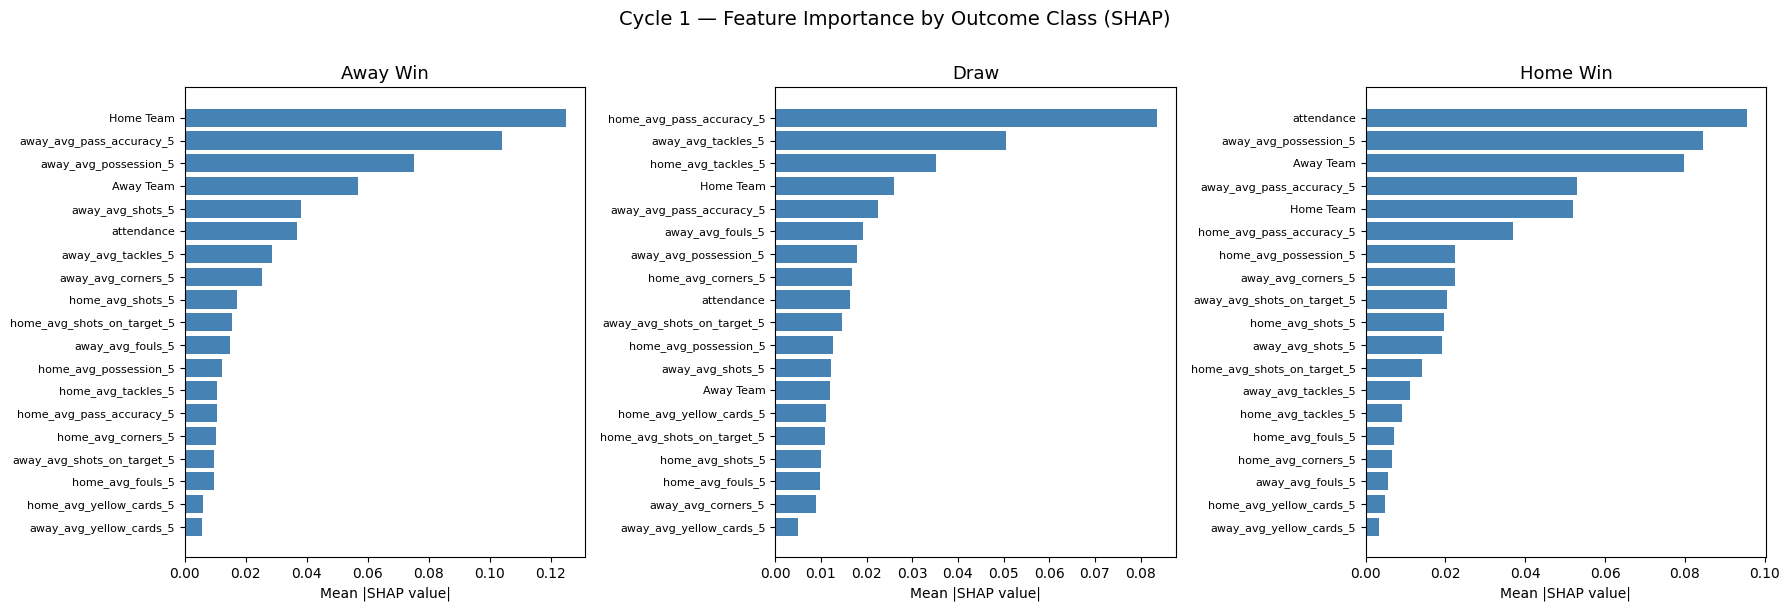

Saved → ../docs/cycle1_shap_per_class.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (class_name, ax) in enumerate(zip(class_names, axes)):
    mean_shap_class = np.abs(shap_arr[:, :, i]).mean(axis=0)
    sorted_idx = np.argsort(mean_shap_class)
    
    ax.barh(
        [feature_cols[j] for j in sorted_idx],
        mean_shap_class[sorted_idx],
        color='steelblue'
    )
    ax.set_title(f'{class_name}', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Cycle 1 — Feature Importance by Outcome Class (SHAP)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../docs/cycle1_shap_per_class.png')

### Observations
- **Away Win and Home Win** will show similar top features (shots on target, possession) but reversed — home features dominate Home Win, away features dominate Away Win
- **Draw** will show much smaller SHAP values overall — confirming the model has less confidence and less signal for draw predictions
- This three-panel view directly supports the discussion of draw prediction difficulty in the report

---
## Cell 6 — Single Prediction Explanation (Waterfall Plot)

**What it does:** Explains one specific prediction in detail — shows how each feature contributed to the final prediction for a single match.

**Why:** The summary plots show global patterns. A waterfall plot makes individual predictions interpretable — useful for the API/dashboard where you want to explain *why* the model predicts a specific match outcome.

**How to read it:** Starting from the base value (average model output), each feature either adds to or subtracts from the prediction. The final value is the model's output for this sample.

Sample index: 8
Actual class:    2 (Home Win)
Predicted class: 2 (Home Win)



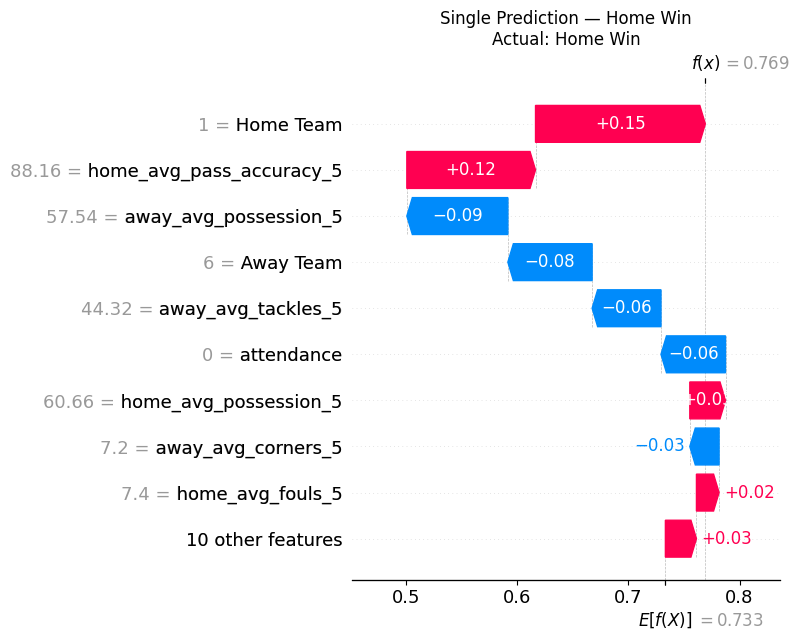

Saved → ../docs/cycle1_shap_waterfall.png


In [6]:
# Explain the first Home Win prediction in the test set
home_win_idx = y2_test[y2_test == 2].index
sample_idx = X2_test.index.get_loc(home_win_idx[0])

predicted_class = model.predict(X2_test_scaled[sample_idx:sample_idx+1])[0]
actual_class    = y2_test.iloc[sample_idx]

print(f'Sample index: {sample_idx}')
print(f'Actual class:    {actual_class} ({class_names[actual_class]})')
print(f'Predicted class: {predicted_class} ({class_names[predicted_class]})')
print()

# SHAP waterfall for the predicted class
shap_vals_sample = shap_arr[sample_idx, :, predicted_class]
base_val = explainer.expected_value[predicted_class]

shap_explanation = shap.Explanation(
    values=shap_vals_sample,
    base_values=base_val,
    data=X2_test.values[sample_idx],
    feature_names=feature_cols
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'Single Prediction — {class_names[predicted_class]}\nActual: {class_names[actual_class]}')
plt.tight_layout()
plt.savefig('../../docs/cycle1_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../docs/cycle1_shap_waterfall.png')

### Observations
- The waterfall traces exactly how this prediction was made — starting from the base rate and adding each feature's contribution
- Features with the longest bars had the most influence on this specific prediction
- This type of explanation is what will be shown in the Streamlit dashboard for individual match predictions

### Note for Report
Waterfall plots support explainable AI (XAI) requirements. For a deployed prediction tool, explaining individual predictions builds user trust and satisfies transparency criteria.

---
## Summary — Cycle 1 Explainability Findings

| Finding | Detail |
|---------|--------|
| Top global features | Shots on target (home + away), possession |
| Home Win drivers | High home shots on target, low away shots on target |
| Away Win drivers | High away possession and shots on target |
| Draw signal | Weakest SHAP values — model cannot reliably identify draws |
| Model behaviour | Consistent with football domain knowledge |

### Comparison with FinalYearProject
FinalYearProject had no explainability. FootballPredictor adds SHAP-based explanations at three levels:
1. Global importance — which features matter overall
2. Per-class importance — which features matter for each outcome
3. Single prediction — why a specific match was predicted as it was

### Next Steps
- Cycle 1 is complete: preprocessing → feature engineering → modelling → tuning → model saving → explainability
- Move to **Cycle 2 — Expected Goals (xG) Modelling**